In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from skimage.segmentation import mark_boundaries
import itertools
import random
import time
import pickle

In [3]:
import sys
sys.path.append("../..")

from coral_mapper_functions import score_map
from coral_mapper import coral_map

In [18]:
import segments_regressor
from skimage.segmentation import find_boundaries

### Loading the connectivity table for the post-processing

In [4]:
connectivity = pd.read_pickle('../../../data/connectivity_table_maupiti')

# Loading the maps

In [5]:
img_rugo_zones = np.load('../../../../coral_mapping/v2/data/pleiades_map_types_5m.npy')
pleiades_img = np.load('../../../../coral_mapping/v2/data/pleiades_ortho_5m.npy')

In [6]:
img_blue = (pleiades_img[1]-np.mean(pleiades_img[1]))/np.std(pleiades_img[1])
img_green = (pleiades_img[2]-np.mean(pleiades_img[2]))/np.std(pleiades_img[2])
img_red = (pleiades_img[3]-np.mean(pleiades_img[3]))/np.std(pleiades_img[3])
img_nir = (pleiades_img[0]-np.mean(pleiades_img[0]))/np.std(pleiades_img[0])

In [13]:
map_test = coral_map([img_blue,img_green,img_red,img_nir], map_img=img_rugo_zones, size_img=5)

In [14]:
classified_pixels = np.where(img_rugo_zones>0)

In [15]:
random.seed(0)
size_subset = 250000
index_combination = list(np.array(classified_pixels).T)
random_train_test = random.sample(index_combination,size_subset)
training_set_indexes_pb = random_train_test[:size_subset//5]
testing_set_indexes_pb = random_train_test[size_subset//5:]

# Analysis of the neighbourhood size

In [22]:
%%time
list_superpixel_size = [3, 5]
list_scores_pb = []
list_scores_smooth = []
list_scores_pp = []
for superpixel_size in list_superpixel_size :
    print('*** COMPUTATION FOR', superpixel_size, '***')
    scores_pb = []
    scores_smooth = []
    scores_pp = []
    for i in range(5):
        map_test = coral_map([img_blue,img_green,img_red,img_nir], map_img=img_rugo_zones, size_img=superpixel_size)
        random.seed(i)

        random_train_test = random.sample(index_combination,size_subset)
        training_set_indexes_pb = random_train_test[:size_subset//5]
        testing_set_indexes_pb = random_train_test[size_subset//5:]

        map_test.train_pixelbased_rf(training_set_indexes_pb, testing_set_indexes_pb, undersampling=0)

        map_test.predict_map_pixelbased_rf()

        predicted_map_pixelbased_rf_classes = np.argmax(map_test.predicted_map_pb_rf,axis=2)+1
        score_pb = score_map(img_rugo_zones,predicted_map_pixelbased_rf_classes,[0,4,5], map_test.segments, training_set_indexes_pb, [], size_superpixel=superpixel_size)

        #smoothing
        map_test.segmentation(use_pb_pred=True, scale=1.5, sigma=1., min_size=40)
        map_test.smooth_pb_rf()
        map_test.smoothed_map_pb_rf = map_test.smoothed_map_pb_rf+1
        smooth_map = np.copy(map_test.smoothed_map_pb_rf)
        score_map_smooth = score_map(img_rugo_zones, smooth_map,[0,4,5], map_test.segments, training_set_indexes_pb, [], size_superpixel=superpixel_size)

        #post-processing
        segments_classes = np.copy(map_test.y_segments_pb_rf_classes)
        boundaries = find_boundaries(map_test.segments)
        adjacent_segments,_ = segments_regressor.find_adjacent_segments(map_test.segments, boundaries)

        list_wrong_neighbours = []
        for i in range(len(adjacent_segments)):
            wrong_neighbours = 0
            s = adjacent_segments[i]
            s_class = segments_classes[i]
            if s_class > 0:
                s_connectivity = connectivity[s_class]
                for j in s:
                    if segments_classes[j]>0:
                        if s_connectivity[segments_classes[j]] == 0 :
                            wrong_neighbours += 1
            list_wrong_neighbours.append(wrong_neighbours/len(s))

        threshold = 0.8
        nb_wrong_segments=0
        for i, value in enumerate(list_wrong_neighbours):
            if value>0:
                #assign the majority of neighbours to this segment
                nb_wrong_segments+=1
                lst_temp = [segments_classes[j] for j in adjacent_segments[i]]
                majority_neighbours = max(set(lst_temp), key=lst_temp.count)
                if majority_neighbours/len(lst_temp) > threshold:
                    segments_classes[i] = majority_neighbours

        new_map = np.copy(map_test.segments)
        for i in range(np.max(map_test.segments)+1):
            new_map[map_test.segments==i] = segments_classes[i]+1

        score_pp = score_map(img_rugo_zones,new_map,[0,4,5], map_test.segments, training_set_indexes_pb, [], size_superpixel=superpixel_size)

        scores_pb.append(score_pb)
        scores_smooth.append(score_map_smooth)
        scores_pp.append(score_pp)
        
    list_scores_pb.append(scores_pb)
    list_scores_smooth.append(scores_smooth)
    list_scores_pp.append(scores_pp)

*** COMPUTATION FOR 3 ***


../..\coral_mapper.py:142: UserWarning: The training set does not contain all the classes. Errors may occur.
  warnings.warn("The training set does not contain all the classes. Errors may occur.")


Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.96125


../..\coral_mapper.py:92: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  segments = felzenszwalb(img_for_segmentation,*args,**kwargs)
../..\coral_mapper.py:142: UserWarning: The training set does not contain all the classes. Errors may occur.
  warnings.warn("The training set does not contain all the classes. Errors may occur.")


Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.96019


...

Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.967355


../..\coral_mapper.py:92: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  segments = felzenszwalb(img_for_segmentation,*args,**kwargs)
../..\coral_mapper.py:142: UserWarning: The training set does not contain all the classes. Errors may occur.
  warnings.warn("The training set does not contain all the classes. Errors may occur.")


Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.96683


../..\coral_mapper.py:92: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  segments = felzenszwalb(img_for_segmentation,*args,**kwargs)


Wall time: 43min 43s


In [37]:
print('(3) Score pixel-based', np.round(np.mean(list_scores_pb[0]),4), np.round(np.std(list_scores_pb[0]),4))
print('(3) Score smoothed', np.round(np.mean(list_scores_smooth[0]),4), np.round(np.std(list_scores_smooth[0]),4))
print('(3) Score post-processing', np.round(np.mean(list_scores_pp[0]),4), np.round(np.std(list_scores_pp[0]),4))

print('(5) Score pixel-based', np.round(np.mean(list_scores_pb[1]),4), np.round(np.std(list_scores_pb[1]),4))
print('(5) Score smoothed', np.round(np.mean(list_scores_smooth[1]),4), np.round(np.std(list_scores_smooth[1]),4))
print('(5) Score post-processing', np.round(np.mean(list_scores_pp[1]),4), np.round(np.std(list_scores_pp[1]),4))

(3) Score pixel-based 0.9229 0.002
(3) Score smoothed 0.9201 0.0014
(3) Score post-processing 0.9216 0.0009
(5) Score pixel-based 0.9128 0.0046
(5) Score smoothed 0.8917 0.0039
(5) Score post-processing 0.8912 0.0047


In [38]:
%%time
list_superpixel_size = [7, 9, 11]
#list_scores_pb = []
#list_scores_smooth = []
#list_scores_pp = []
for superpixel_size in list_superpixel_size :
    print('*** COMPUTATION FOR', superpixel_size, '***')
    scores_pb = []
    scores_smooth = []
    scores_pp = []
    for i in range(5):
        map_test = coral_map([img_blue,img_green,img_red,img_nir], map_img=img_rugo_zones, size_img=superpixel_size)
        random.seed(i)

        random_train_test = random.sample(index_combination,size_subset)
        training_set_indexes_pb = random_train_test[:size_subset//5]
        testing_set_indexes_pb = random_train_test[size_subset//5:]

        map_test.train_pixelbased_rf(training_set_indexes_pb, testing_set_indexes_pb, undersampling=0)

        map_test.predict_map_pixelbased_rf()

        predicted_map_pixelbased_rf_classes = np.argmax(map_test.predicted_map_pb_rf,axis=2)+1
        score_pb = score_map(img_rugo_zones,predicted_map_pixelbased_rf_classes,[0,4,5], map_test.segments, training_set_indexes_pb, [], size_superpixel=superpixel_size)

        #smoothing
        map_test.segmentation(use_pb_pred=True, scale=1.5, sigma=1., min_size=40)
        map_test.smooth_pb_rf()
        map_test.smoothed_map_pb_rf = map_test.smoothed_map_pb_rf+1
        smooth_map = np.copy(map_test.smoothed_map_pb_rf)
        score_map_smooth = score_map(img_rugo_zones, smooth_map,[0,4,5], map_test.segments, training_set_indexes_pb, [], size_superpixel=superpixel_size)

        #post-processing
        segments_classes = np.copy(map_test.y_segments_pb_rf_classes)
        boundaries = find_boundaries(map_test.segments)
        adjacent_segments,_ = segments_regressor.find_adjacent_segments(map_test.segments, boundaries)

        list_wrong_neighbours = []
        for i in range(len(adjacent_segments)):
            wrong_neighbours = 0
            s = adjacent_segments[i]
            s_class = segments_classes[i]
            if s_class > 0:
                s_connectivity = connectivity[s_class]
                for j in s:
                    if segments_classes[j]>0:
                        if s_connectivity[segments_classes[j]] == 0 :
                            wrong_neighbours += 1
            list_wrong_neighbours.append(wrong_neighbours/len(s))

        threshold = 0.8
        nb_wrong_segments=0
        for i, value in enumerate(list_wrong_neighbours):
            if value>0:
                #assign the majority of neighbours to this segment
                nb_wrong_segments+=1
                lst_temp = [segments_classes[j] for j in adjacent_segments[i]]
                majority_neighbours = max(set(lst_temp), key=lst_temp.count)
                if majority_neighbours/len(lst_temp) > threshold:
                    segments_classes[i] = majority_neighbours

        new_map = np.copy(map_test.segments)
        for i in range(np.max(map_test.segments)+1):
            new_map[map_test.segments==i] = segments_classes[i]+1

        score_pp = score_map(img_rugo_zones,new_map,[0,4,5], map_test.segments, training_set_indexes_pb, [], size_superpixel=superpixel_size)

        scores_pb.append(score_pb)
        scores_smooth.append(score_map_smooth)
        scores_pp.append(score_pp)
        
    list_scores_pb.append(scores_pb)
    list_scores_smooth.append(scores_smooth)
    list_scores_pp.append(scores_pp)

*** COMPUTATION FOR 7 ***


../..\coral_mapper.py:142: UserWarning: The training set does not contain all the classes. Errors may occur.
  warnings.warn("The training set does not contain all the classes. Errors may occur.")


Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.970335


../..\coral_mapper.py:92: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  segments = felzenszwalb(img_for_segmentation,*args,**kwargs)
../..\coral_mapper.py:142: UserWarning: The training set does not contain all the classes. Errors may occur.
  warnings.warn("The training set does not contain all the classes. Errors may occur.")


Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.9697


...

Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.97673


../..\coral_mapper.py:92: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  segments = felzenszwalb(img_for_segmentation,*args,**kwargs)
../..\coral_mapper.py:142: UserWarning: The training set does not contain all the classes. Errors may occur.
  warnings.warn("The training set does not contain all the classes. Errors may occur.")


Creating the labels for each superpixel...
Creating the features for each superpixel...
Training the Random Forest classifier...
Validation accuracy: 0.97649


../..\coral_mapper.py:92: RuntimeWarning: Got image with third dimension of 4. This image will be interpreted as a multichannel 2d image, which may not be intended.
  segments = felzenszwalb(img_for_segmentation,*args,**kwargs)


Wall time: 2h 25min 36s


In [40]:
print('(3) Score pixel-based', np.round(np.mean(list_scores_pb[0]),4), np.round(np.std(list_scores_pb[0]),4))
print('(3) Score smoothed', np.round(np.mean(list_scores_smooth[0]),4), np.round(np.std(list_scores_smooth[0]),4))
print('(3) Score post-processing', np.round(np.mean(list_scores_pp[0]),4), np.round(np.std(list_scores_pp[0]),4))
print('---')
print('(5) Score pixel-based', np.round(np.mean(list_scores_pb[1]),4), np.round(np.std(list_scores_pb[1]),4))
print('(5) Score smoothed', np.round(np.mean(list_scores_smooth[1]),4), np.round(np.std(list_scores_smooth[1]),4))
print('(5) Score post-processing', np.round(np.mean(list_scores_pp[1]),4), np.round(np.std(list_scores_pp[1]),4))
print('---')
print('(7) Score pixel-based', np.round(np.mean(list_scores_pb[2]),4), np.round(np.std(list_scores_pb[2]),4))
print('(7) Score smoothed', np.round(np.mean(list_scores_smooth[2]),4), np.round(np.std(list_scores_smooth[2]),4))
print('(7) Score post-processing', np.round(np.mean(list_scores_pp[2]),4), np.round(np.std(list_scores_pp[2]),4))
print('---')
print('(9) Score pixel-based', np.round(np.mean(list_scores_pb[3]),4), np.round(np.std(list_scores_pb[3]),4))
print('(9) Score smoothed', np.round(np.mean(list_scores_smooth[3]),4), np.round(np.std(list_scores_smooth[3]),4))
print('(9) Score post-processing', np.round(np.mean(list_scores_pp[3]),4), np.round(np.std(list_scores_pp[3]),4))
print('---')
print('(11) Score pixel-based', np.round(np.mean(list_scores_pb[4]),4), np.round(np.std(list_scores_pb[4]),4))
print('(11) Score smoothed', np.round(np.mean(list_scores_smooth[4]),4), np.round(np.std(list_scores_smooth[4]),4))
print('(11) Score post-processing', np.round(np.mean(list_scores_pp[4]),4), np.round(np.std(list_scores_pp[4]),4))

(3) Score pixel-based 0.9229 0.002
(3) Score smoothed 0.9201 0.0014
(3) Score post-processing 0.9216 0.0009
---
(5) Score pixel-based 0.9128 0.0046
(5) Score smoothed 0.8917 0.0039
(5) Score post-processing 0.8912 0.0047
---
(7) Score pixel-based 0.8725 0.0113
(7) Score smoothed 0.8223 0.0111
(7) Score post-processing 0.8188 0.0107
---
(9) Score pixel-based 0.8227 0.0435
(9) Score smoothed 0.7533 0.05
(9) Score post-processing 0.7458 0.0547
---
(11) Score pixel-based 0.803 0.1103
(11) Score smoothed 0.6829 0.153
(11) Score post-processing 0.6764 0.1463


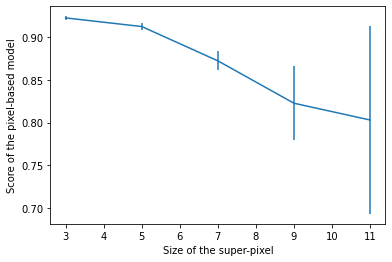

In [51]:
plt.errorbar([3, 5, 7, 9, 11], np.mean(list_scores_pb, axis=1), np.std(list_scores_pb, axis=1))
plt.xlabel('Size of the super-pixel')
plt.ylabel('Score of the pixel-based model')
plt.savefig('neighbourhood_size_5m_errorbar.png', dpi=100)
plt.show()